# Bartlett's Test for Equal Variances

**Bartlett's test** checks whether k groups have equal population variances. It uses the likelihood ratio principle and is more powerful than Levene's test when data is normally distributed, but highly sensitive to non-normality.

| Property | Value |
|---|---|
| **H₀** | σ₁² = σ₂² = ⋯ = σₖ² |
| **H₁** | At least one variance differs |
| **Test statistic** | χ² (chi-square approximation) |
| **df** | k − 1 |
| **Assumption** | Data must be approximately normal |
| **Alternative** | Use Levene's test if normality is questionable |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

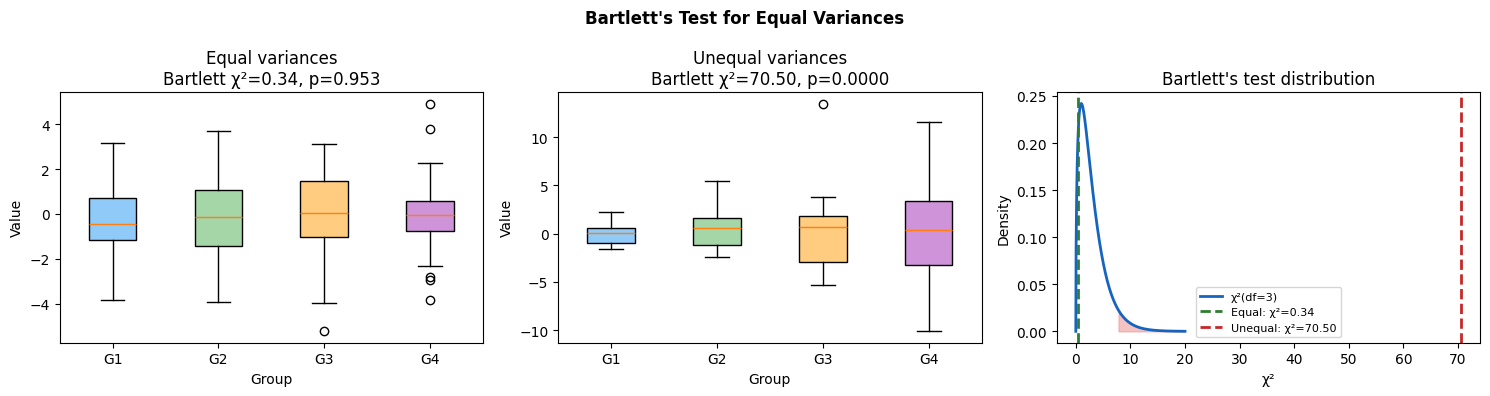

Equal: SDs=['1.80', '1.86', '1.98', '1.82'], χ²=0.335, p=0.9533
Unequal: SDs=['1.02', '1.89', '3.68', '5.19'], χ²=70.505, p=0.0000


In [2]:
np.random.seed(42)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Bartlett's Test for Equal Variances", fontsize=12, fontweight='bold')

# Equal variances
k = 4; n = 30
equal_groups = [np.random.normal(0, 2.0, n) for _ in range(k)]
# Unequal variances
unequal_groups = [np.random.normal(0, s, n) for s in [1.0, 2.0, 3.5, 5.0]]

stat_eq, p_eq = stats.bartlett(*equal_groups)
stat_uneq, p_uneq = stats.bartlett(*unequal_groups)

# Panel 1: boxplots of equal groups
bp1 = axes[0].boxplot(equal_groups, labels=[f'G{i+1}' for i in range(k)],
                      patch_artist=True)
for patch, color in zip(bp1['boxes'], ['#90CAF9','#A5D6A7','#FFCC80','#CE93D8']):
    patch.set_facecolor(color)
axes[0].set_title(f'Equal variances\nBartlett χ²={stat_eq:.2f}, p={p_eq:.3f}')
axes[0].set_xlabel('Group'); axes[0].set_ylabel('Value')

# Panel 2: boxplots of unequal groups
bp2 = axes[1].boxplot(unequal_groups, labels=[f'G{i+1}' for i in range(k)],
                      patch_artist=True)
for patch, color in zip(bp2['boxes'], ['#90CAF9','#A5D6A7','#FFCC80','#CE93D8']):
    patch.set_facecolor(color)
axes[1].set_title(f'Unequal variances\nBartlett χ²={stat_uneq:.2f}, p={p_uneq:.4f}')
axes[1].set_xlabel('Group'); axes[1].set_ylabel('Value')

# Panel 3: chi-square distribution
chi2_range = np.linspace(0, 20, 400)
chi2_pdf = stats.chi2.pdf(chi2_range, df=k-1)
chi2_crit = stats.chi2.ppf(0.95, df=k-1)
axes[2].plot(chi2_range, chi2_pdf, color='#1565C0', lw=2, label=f'χ²(df={k-1})')
axes[2].fill_between(chi2_range, chi2_pdf, where=chi2_range >= chi2_crit, color='#EF9A9A', alpha=0.6)
axes[2].axvline(stat_eq,   color='#2E7D32', lw=2, ls='--', label=f'Equal: χ²={stat_eq:.2f}')
axes[2].axvline(stat_uneq, color='#C62828', lw=2, ls='--', label=f'Unequal: χ²={stat_uneq:.2f}')
axes[2].set_title(f"Bartlett's test distribution"); axes[2].set_xlabel('χ²')
axes[2].set_ylabel('Density'); axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

for label, grps, st, pv in [('Equal', equal_groups, stat_eq, p_eq), ('Unequal', unequal_groups, stat_uneq, p_uneq)]:
    sds = [g.std(ddof=1) for g in grps]
    print(f'{label}: SDs={[f"{s:.2f}" for s in sds]}, χ²={st:.3f}, p={pv:.4f}')

## Key Takeaways

| | |
|---|---|
| **Normal data** | Bartlett's is more powerful than Levene's when normality holds |
| **Non-normal data** | Bartlett's inflates Type I error — use Levene's test instead |
| **Before ANOVA** | Test equal-variance assumption before pooled F-test |
| **Rule of thumb** | If max(s)/min(s) > 2, investigate further |
| **χ² approximation** | Works well for n ≥ 5 per group |
| **Levene alternative** | Median-based Levene is robust to non-normality |